In [12]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
df = pd.read_csv("Titanic-Dataset.csv")
df.shape

(891, 12)

In [14]:
df_clean = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["LogFare"] = np.log1p(df_clean["Fare"])

df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})
df_clean["Embarked"] = df_clean["Embarked"].map({"S": 0, "C": 1, "Q": 2})

df_clean = df_clean.drop(columns=["SibSp", "Parch", "Fare"])

print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Shape after prep:", df_clean.shape)
df_clean.head()

Missing values remaining: 0
Shape after prep: (891, 8)


,Survived,Pclass,Sex,Age,Embarked,FamilySize,IsAlone,LogFare
0,0,3,0,22.0,0,2,0,2.110213
1,1,1,1,38.0,1,2,0,4.280593
2,1,3,1,26.0,0,1,1,2.188856
3,1,1,1,35.0,0,2,0,3.990834
4,0,3,0,35.0,0,1,1,2.202765


In [15]:
FEATURES = ["Pclass", "Sex", "Age", "LogFare", "Embarked", "FamilySize", "IsAlone"]
TARGET = "Survived"

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nSurvival rate in train: {y_train.mean():.3f}")
print(f"Survival rate in test:  {y_test.mean():.3f}")

Training set:  668 rows
Test set:      223 rows

Survival rate in train: 0.383
Survival rate in test:  0.386


In [16]:
majority_class = y_train.mode()[0] #mode gives me the most repeat value, highest frequency
naive_preds = np.full(len(y_test), majority_class)
naive_accuracy = accuracy_score(y_test, naive_preds)

print(f"Majority class: {majority_class} (Did not survive)")
print(f"Naive baseline accuracy: {naive_accuracy:.3f}")
print()
print("Interpretation: A model that always predicts 'did not survive'")
print(f"would be correct {naive_accuracy*100:.1f}% of the time — without learning anything.")
print(f"Our model must beat {naive_accuracy:.3f} to be worth using.")

Majority class: 0 (Did not survive)
Naive baseline accuracy: 0.614

Interpretation: A model that always predicts 'did not survive'
would be correct 61.4% of the time — without learning anything.
Our model must beat 0.614 to be worth using.


In [17]:
# 1. Initialize the StandardScaler. 
# This tool standardizes features by removing the mean and scaling them to unit variance (making the data easier for the model to learn).
scaler = StandardScaler()

# 2. Fit the scaler to the training data and transform it.
# 'fit' computes the mean and standard deviation of X_train.
# 'transform' applies the scaling to X_train. 
# We do this together using 'fit_transform' and ONLY on the training data to prevent data leakage.
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testing data.
# We use 'transform' (NOT 'fit_transform') so that the test data is scaled using the exact same mean and standard deviation learned from the training data.
X_test_scaled  = scaler.transform(X_test)  

# 4. Initialize the Logistic Regression model.
# 'random_state=42' ensures that the results are reproducible if you run the code multiple times.
# 'max_iter=1000' increases the maximum number of iterations allowed for the solver to converge (the default is 100, which is sometimes too low for unscaled or complex data).
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# 5. Train (fit) the model.
# The model learns the relationship between the scaled training features (X_train_scaled) and their corresponding labels (y_train).
log_reg.fit(X_train_scaled, y_train)

# 6. Output a success message.
print("Model trained successfully.")


Model trained successfully.


In [18]:
# 1. Generate predictions for the test data using our trained model.
# 'predict' outputs the exact class labels (e.g., 0 for Did Not Survive, 1 for Survived).
y_pred  = log_reg.predict(X_test_scaled)

# 2. Get the predicted probabilities for the test data.
# 'predict_proba' returns an array with the probabilities of each class (e.g., [prob_class_0, prob_class_1]).
# We slice with '[:, 1]' to extract only the probabilities of the positive class (class 1: Survived).
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1] 

# 3. Calculate the overall accuracy of the model.
# This checks how many predicted labels (y_pred) correctly match the true labels (y_test) overall.
acc = accuracy_score(y_test, y_pred)

# 4. Calculate the ROC-AUC score (Receiver Operating Characteristic - Area Under Curve).
# This evaluates how well the model can distinguish between the two classes based on their predicted probabilities. 
# A score of 0.5 is random guessing, and 1.0 is perfect prediction.
auc = roc_auc_score(y_test, y_proba)

# 5. Print a nicely formatted summary of the model's performance.
print("=" * 40)

# The naive baseline assumes we just predict the majority class for everyone.
print(f"  Naive Baseline Accuracy : {naive_accuracy:.3f}")

# The accuracy of our logistic regression model, and how much better it is compared to the baseline.
print(f"  Logistic Regression Acc : {acc:.3f}  (+{acc - naive_accuracy:.3f} vs baseline)")

# Our calculated ROC-AUC score. #a way to quantify the true positivies and true negatives, a way to get the true accuracy of the score
print(f"  ROC-AUC Score           : {auc:.3f}")
print("=" * 40)

# 6. Generate and print a classification report.
# This provides detailed metrics: Precision, Recall, and F1-Score for BOTH classes individually.
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))


  Naive Baseline Accuracy : 0.614
  Logistic Regression Acc : 0.780  (+0.166 vs baseline)
  ROC-AUC Score           : 0.843
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.82      0.82       137
       Survived       0.71      0.72      0.72        86

       accuracy                           0.78       223
      macro avg       0.77      0.77      0.77       223
   weighted avg       0.78      0.78      0.78       223



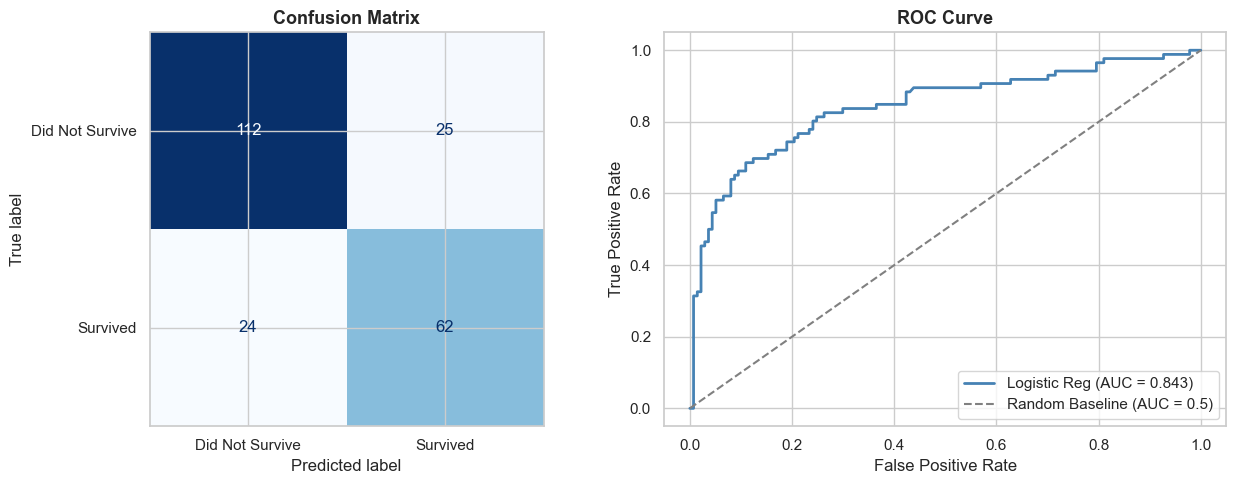

In [19]:
# 1. Create a figure and a set of subplots. 
# '1, 2' means we want 1 row and 2 columns (two plots side-by-side).
# 'figsize=(13, 5)' sets the total width to 13 inches and height to 5 inches.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#########################
# Plot 1: Confusion Matrix 
#########################

# 2. Calculate the confusion matrix.
# It compares the true labels (y_test) against the model's predictions (y_pred)
# to see True Positives, False Positives, True Negatives, and False Negatives.
cm = confusion_matrix(y_test, y_pred)

# 3. Initialize the display object for the confusion matrix.
# We map the numeric classes (0, 1) to readable labels ("Did Not Survive", "Survived").
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])

# 4. Plot the confusion matrix on the first subplot (axes[0]).
# 'colorbar=False' hides the side color scale, and 'cmap="Blues"' uses a blue color theme.
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")

# 5. Set the title for the first plot and make it bold.
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")


#########################
# Plot 2: ROC Curve
#########################

# 6. Calculate the False Positive Rate (fpr) and True Positive Rate (tpr) at various thresholds.
# We use 'y_proba' (model's predicted probabilities) against actual labels (y_test).
# The third return item (thresholds) is ignored using '_'.
fpr, tpr, _ = roc_curve(y_test, y_proba)

# 7. Plot the ROC curve for the Logistic Regression model on the second subplot (axes[1]).
# We label it with the previously calculated AUC (Area Under the Curve) score.
axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Reg (AUC = {auc:.3f})")

# 8. Plot a diagonal dashed line representing a "Random Guessing" baseline.
# A random model will have an equal False Positive Rate and True Positive Rate (AUC = 0.5).
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline (AUC = 0.5)")

# 9. Set the labels for the X and Y axes on the ROC curve plot.
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

# 10. Set the title for the second plot and make it bold.
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")

# 11. Add a legend to the second plot so we know which line is which.
axes[1].legend()


#########################
# Final Display
#########################

# 12. Adjust the padding/spacing between plots so they don't overlap.
plt.tight_layout()

# 13. Render and display the plots!
plt.show()


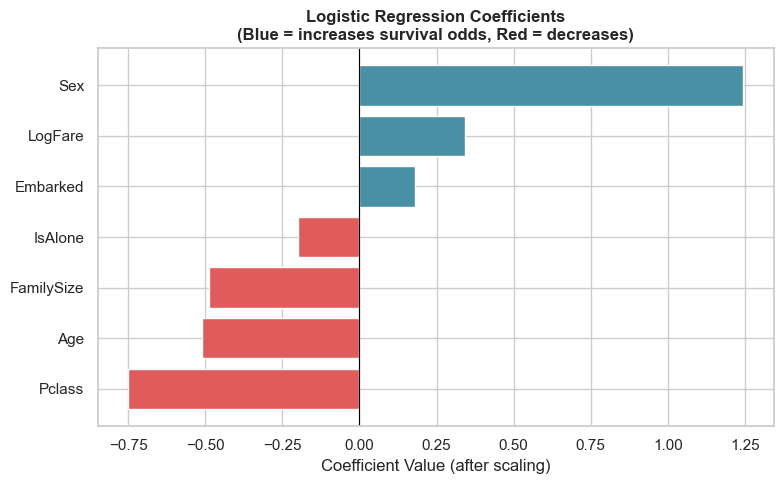

   Feature  Coefficient
    Pclass    -0.748779
       Age    -0.510150
FamilySize    -0.488967
   IsAlone    -0.199410
  Embarked     0.179583
   LogFare     0.343645
       Sex     1.244365


In [20]:
# 1. Create a DataFrame to store the feature names and their corresponding coefficients.
# 'log_reg.coef_[0]' contains the learned weights for each feature in the logistic regression model.
# A positive coefficient means the feature increases the likelihood of survival, 
# while a negative coefficient decreases it.
# We then use '.sort_values("Coefficient")' to order them from most negative to most positive.
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient")

# 2. Assign colors to each bar based on the value of the coefficient.
# List comprehension iterates through the sorted coefficients.
# It assigns red ("#e05c5c") for negative values and blue ("#4a90a4") for positive values.
colors = ["#e05c5c" if c < 0 else "#4a90a4" for c in coef_df["Coefficient"]]

# 3. Set up the figure for the bar chart.
# 'figsize=(8, 5)' sets the width to 8 inches and height to 5 inches.
plt.figure(figsize=(8, 5))

# 4. Create a horizontal bar chart (`barh`).
# The Y-axis gets the feature names, and the X-axis gets the coefficient values.
# 'color=colors' applies the red/blue list we generated above.
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)

# 5. Add a vertical black reference line exactly at 0.
# This makes it visually easy to distinguish positive vs. negative impact.
plt.axvline(0, color="black", linewidth=0.8)

# 6. Set the title of the chart, adding a line break '\n' for readability.
# Also adjust the font size and make it bold.
plt.title("Logistic Regression Coefficients\n(Blue = increases survival odds, Red = decreases)",
          fontsize=12, fontweight="bold")

# 7. Set the label for the X-axis.
# Note that coefficients are relative to the scaled features, not their original units.
plt.xlabel("Coefficient Value (after scaling)")

# 8. Clean up the padding/spacing so no labels get cut off off-screen.
plt.tight_layout()

# 9. Render and show the plot!
plt.show()

# 10. Finally, print the raw data frame directly to the console.
# 'to_string(index=False)' hides the random integer row numbers for a cleaner output table.
print(coef_df.to_string(index=False))


In [27]:
# Import the Pipeline utility from Scikit-Learn.
# This ensures a series of data transformations happen sequentially and automatically.
from sklearn.pipeline import Pipeline

# 1. Create a Pipeline with our preprocessing and modeling steps.
# Using a pipeline is crucial for cross-validation because it guarantees that 'fit_transform' 
# is ONLY applied to the training folds, and 'transform' is applied to the validation folds.
# If we pre-scaled all the data first, information from the validation fold would "leak" into the training fold.
pipe = Pipeline([
    ("scaler", StandardScaler()),                                  # Step 1: Scale the features.
    ("model", LogisticRegression(random_state=42, max_iter=1000))  # Step 2: Fit the Logistic Regression model.
])

# 2. Perform 5-Fold Cross-Validation.
# It splits the full dataset (X, y) into 5 equal parts (folds). It trains 5 different models, 
# each time using 4 folds for training and 1 fold for testing, rotating the test fold every time.
# Setting 'scoring="accuracy"' means it will evaluate each model based on how many predictions were correct.
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")

# 3. Print the header.
print("5-Fold Cross-Validation Accuracy:")

# 4. Iterate through the generated accuracy scores and print them.
# The `enumerate(..., 1)` starts our counter `i` at 1 instead of 0 for easier readability.
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")

# 5. Print the overall Mean and Standard Deviation (Std) across the 5 models.
# The mean tells us how the model performs on average on unseen data.
print(f"\n  Mean:  {cv_scores.mean():.3f}")

# The standard deviation tells us how much the performance fluctuated depending on which data fold it used.
print(f"  Std:   {cv_scores.std():.3f}")

# 6. Add some vertical spacing and print an interpretive note about the output.
print()
print("A low std (< 0.02) means the model is stable across different data splits.")


5-Fold Cross-Validation Accuracy:
  Fold 1: 0.760
  Fold 2: 0.787
  Fold 3: 0.781
  Fold 4: 0.798
  Fold 5: 0.826

  Mean:  0.790
  Std:   0.022

A low std (< 0.02) means the model is stable across different data splits.


In [28]:
# Import joblib, a widely used library for fast object serialization in Python. 
# It is specifically optimized for saving large datasets and machine learning models 
# (like those from scikit-learn) with minimal overhead.
import joblib

# Serialize (save) the fitted 'pipe' object to a file on your computer.
# The 'pipe' contains both our fitted StandardScaler and our trained LogisticRegression model.
# By saving it as a .pkl (pickle) file, we can easily load it later in a different script 
# (using joblib.load) to make predictions on new data without having to retrain the model.
joblib.dump(pipe, "titanic_logistic_model.pkl")


['titanic_logistic_model.pkl']

Part 2 — Linear Regression on House Prices
Go to this comp and join the comp: kaggle.com/c/house-prices-advanced-regression-techniques

kaggle competitions download -c house-prices-advanced-regression-techniques
unzip house-prices-advanced-regression-techniques.zip

In [30]:
# Read the Housing training dataset from Kaggle.
houses = pd.read_csv("train.csv") 

# Preview the data structure.
houses.head()

# Display the shape and some statistical properties regarding the target label (SalePrice).
print("Shape:", houses.shape)
print("\nTarget — SalePrice:")
print(houses["SalePrice"].describe().apply(lambda x: f"${x:,.0f}"))


Shape: (1460, 81)

Target — SalePrice:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: str


In [31]:
# Show all rows when generating the EDA (Exploratory Data Analysis) table.
pd.set_option('display.max_rows', None)

# Build a summary DataFrame providing a high-level view of every column:
# It details data types, unique string/number counts, and missing value counts/percentages.
eda_summary = pd.DataFrame({
    "dtype": houses.dtypes,
    "num_unique": houses.nunique(),
    "num_missing": houses.isnull().sum(),
    "missing_pct": houses.isnull().mean() * 100
})

# Sort by the number of unique entries to more easily spot binary/categorical columns vs continuous ones.
eda_summary.sort_values("num_unique")


,dtype,num_unique,num_missing,missing_pct
Alley,str,2,1369,93.767123
Street,str,2,0,0.000000
Utilities,str,2,0,0.000000
CentralAir,str,2,0,0.000000
MasVnrType,str,3,872,59.726027
HalfBath,int64,3,0,0.000000
GarageFinish,str,3,81,5.547945
LandSlope,str,3,0,0.000000
BsmtHalfBath,int64,3,0,0.000000
PavedDrive,str,3,0,0.000000


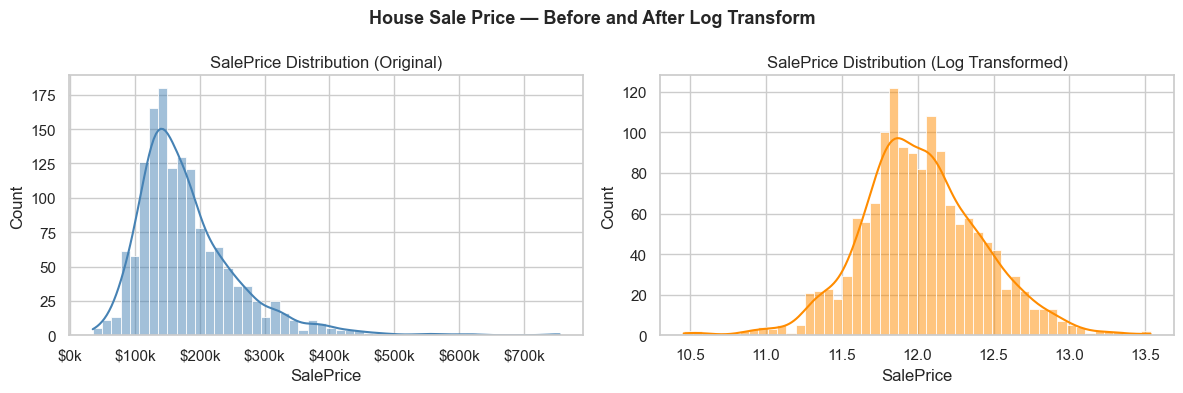

Original skew:          1.883
Log-transformed skew:   0.121

Linear regression assumes the target is roughly normally distributed.
High skew violates that assumption — log transform fixes it.


In [32]:
# Create a 1x2 plotting grid to display side-by-side distributions.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the raw, original house prices on the left.
# Most regression models struggle when targets have heavily skewed "tails" (extreme outliers).
sns.histplot(houses["SalePrice"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice Distribution (Original)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# Apply a mathematical Log Transformation [ np.log(1 + x) ] and plot it on the right.
# This "pulls in" the extreme right-tail making the distribution look much closer to a normal bell-curve!
sns.histplot(np.log1p(houses["SalePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("SalePrice Distribution (Log Transformed)")

plt.suptitle("House Sale Price — Before and After Log Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print mathematical statistical skew metrics.
print(f"Original skew:          {houses['SalePrice'].skew():.3f}")
print(f"Log-transformed skew:   {np.log1p(houses['SalePrice']).skew():.3f}")
print()
print("Linear regression assumes the target is roughly normally distributed.")
print("High skew violates that assumption — log transform fixes it.")


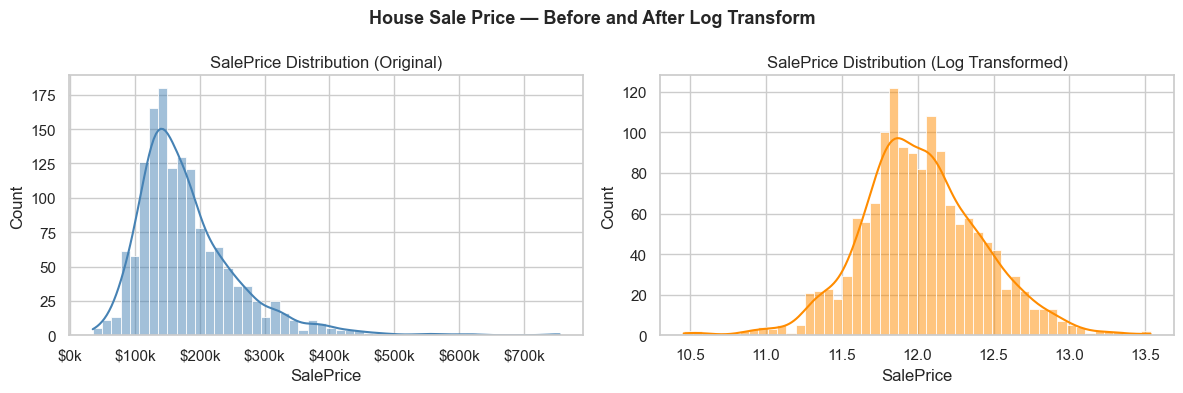

Original skew:          1.883
Log-transformed skew:   0.121

Linear regression assumes the target is roughly normally distributed.
High skew violates that assumption — log transform fixes it.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(houses["SalePrice"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice Distribution (Original)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.histplot(np.log1p(houses["SalePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("SalePrice Distribution (Log Transformed)")

plt.suptitle("House Sale Price — Before and After Log Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Original skew:          {houses['SalePrice'].skew():.3f}")
print(f"Log-transformed skew:   {np.log1p(houses['SalePrice']).skew():.3f}")
print()
print("Linear regression assumes the target is roughly normally distributed.")
print("High skew violates that assumption — log transform fixes it.")

In [34]:
# Select a concise list of high-impact continuous numerical features for simplicity.
HOUSE_FEATURES = [
    "GrLivArea",      
    "OverallQual",    
    "GarageCars",     
    "TotalBsmtSF",    
    "FullBath",       
    "YearBuilt",      
    "TotRmsAbvGrd",   
]

# Create a clean dataframe that drops any row missing one of these specific features or the target.
houses_clean = houses[HOUSE_FEATURES + ["SalePrice"]].dropna()

# Generate the Log-Transformed Target we established was necessary in the previous cell.
houses_clean["LogSalePrice"] = np.log1p(houses_clean["SalePrice"])

# Output confirmation.
print(f"Rows after dropping any missing: {len(houses_clean)}")
houses_clean[HOUSE_FEATURES].describe().round(1)


Rows after dropping any missing: 1460


,GrLivArea,OverallQual,GarageCars,TotalBsmtSF,FullBath,YearBuilt,TotRmsAbvGrd
count,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,1515.5,6.1,1.8,1057.4,1.6,1971.3,6.5
std,525.5,1.4,0.7,438.7,0.6,30.2,1.6
min,334.0,1.0,0.0,0.0,0.0,1872.0,2.0
25%,1129.5,5.0,1.0,795.8,1.0,1954.0,5.0
50%,1464.0,6.0,2.0,991.5,2.0,1973.0,6.0
75%,1776.8,7.0,2.0,1298.2,2.0,2000.0,7.0
max,5642.0,10.0,4.0,6110.0,3.0,2010.0,14.0


C:\Users\siste\AppData\Local\Temp\ipykernel_7396\225139967.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x="Correlation", y="Feature", palette="coolwarm")


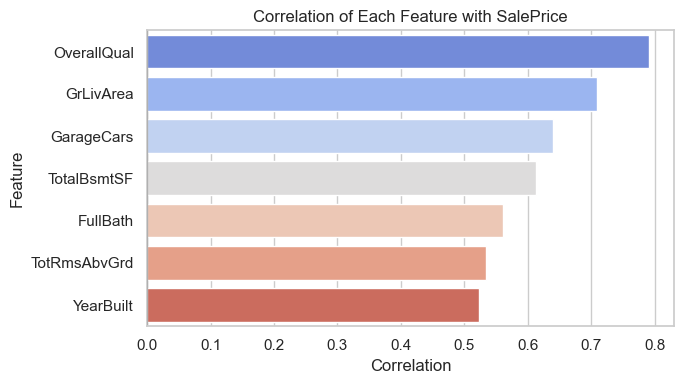

In [35]:
# Import seaborn (again, just in case).
import seaborn as sns

# Calculate mathematical correlation (Pearson's r) between every feature and the precise SalePrice.
# '1.0' means perfect positive correlation, '-1.0' means perfect negative correlation.
# We then drop the 1.0 correlation of SalePrice to itself, and sort them descending.
corr_with_price = houses_clean[HOUSE_FEATURES + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

# Convert the Series into a DataFrame for easier plotting.
corr_df = corr_with_price.reset_index()
corr_df.columns = ["Feature", "Correlation"]

# Plot the correlations as an organized horizontal bar chart.
plt.figure(figsize=(7, 4))
sns.barplot(data=corr_df, x="Correlation", y="Feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Each Feature with SalePrice")
plt.tight_layout()
plt.show()


In [36]:
# Establish X (Features) and y (Target)
X_h = houses_clean[HOUSE_FEATURES]
y_h = houses_clean["LogSalePrice"]

# Perform an 80/20 train-test split for Validation testing later.
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

# -----------------
# BASELINE CALCULATION 
# Calculate what the error would look like if we just guessed the 'Average' house price for every house.
mean_log_price = y_h_train.mean()
naive_preds_h  = np.full(len(y_h_test), mean_log_price)

# Calculate naive Root Mean Squared Error (RMSE) on the log-scale.
naive_rmse = np.sqrt(mean_squared_error(y_h_test, naive_preds_h))
# Inverse the log math (`expm1`) to see roughly how many raw dollars off a naive guess is.
naive_rmse_dollars = np.expm1(mean_log_price + naive_rmse) - np.expm1(mean_log_price)

print(f"Naive baseline (predict mean log price):")
print(f"  RMSE (log scale):  {naive_rmse:.4f}")
print(f"  Approximate error in dollars: ${naive_rmse_dollars:,.0f}")
# -----------------

# Scale all housing data based to Z-scores using parameters learned ONLY from the training set.
scaler_h = StandardScaler()
X_h_train_scaled = scaler_h.fit_transform(X_h_train)
X_h_test_scaled  = scaler_h.transform(X_h_test)

# Initialize and train our Linear Regression model to map features to house prices.
lin_reg = LinearRegression()
lin_reg.fit(X_h_train_scaled, y_h_train)

print("\nLinear regression trained.")


Naive baseline (predict mean log price):
  RMSE (log scale):  0.4332
  Approximate error in dollars: $91,002

Linear regression trained.


In [37]:
# Issue actual predictions from the trained model onto the unseen test data.
y_h_pred = lin_reg.predict(X_h_test_scaled)

# Calculate model evaluation metrics:
# RMSE: Standard heavily-punishing distance measurement.
rmse = np.sqrt(mean_squared_error(y_h_test, y_h_pred))
# MAE: Literally the average distance a prediction is off.
mae  = mean_absolute_error(y_h_test, y_h_pred)
# R²: The percentage of variance in house prices our model algorithms can accurately explain.
r2   = r2_score(y_h_test, y_h_pred)

# Revert predictions from Log scale back to literal dollars to make error interpretable.
y_h_test_dollars = np.expm1(y_h_test)
y_h_pred_dollars = np.expm1(y_h_pred)
# See how far off we are in real money compared to the Naive approach.
rmse_dollars = np.sqrt(mean_squared_error(y_h_test_dollars, y_h_pred_dollars))

# Print our findings formatted clearly.
print("=" * 50)
print(f"  Naive Baseline RMSE (log): {naive_rmse:.4f}")
print(f"  Linear Regression RMSE  : {rmse:.4f}  ({'-' if rmse < naive_rmse else '+'}{ abs(rmse - naive_rmse):.4f} vs baseline)")
print()
print(f"  MAE  (log scale): {mae:.4f}")
print(f"  R²   Score:       {r2:.3f}")
print("=" * 50)
print()
print("R² interpretation:")
print(f"  {r2:.3f} means the model explains {r2*100:.1f}% of the variance in house prices")
print("  R² of 1.0 = perfect. R² of 0.0 = as good as predicting the mean (our baseline).")


  Naive Baseline RMSE (log): 0.4332
  Linear Regression RMSE  : 0.1740  (-0.2592 vs baseline)

  MAE  (log scale): 0.1212
  R²   Score:       0.838

R² interpretation:
  0.838 means the model explains 83.8% of the variance in house prices
  R² of 1.0 = perfect. R² of 0.0 = as good as predicting the mean (our baseline).


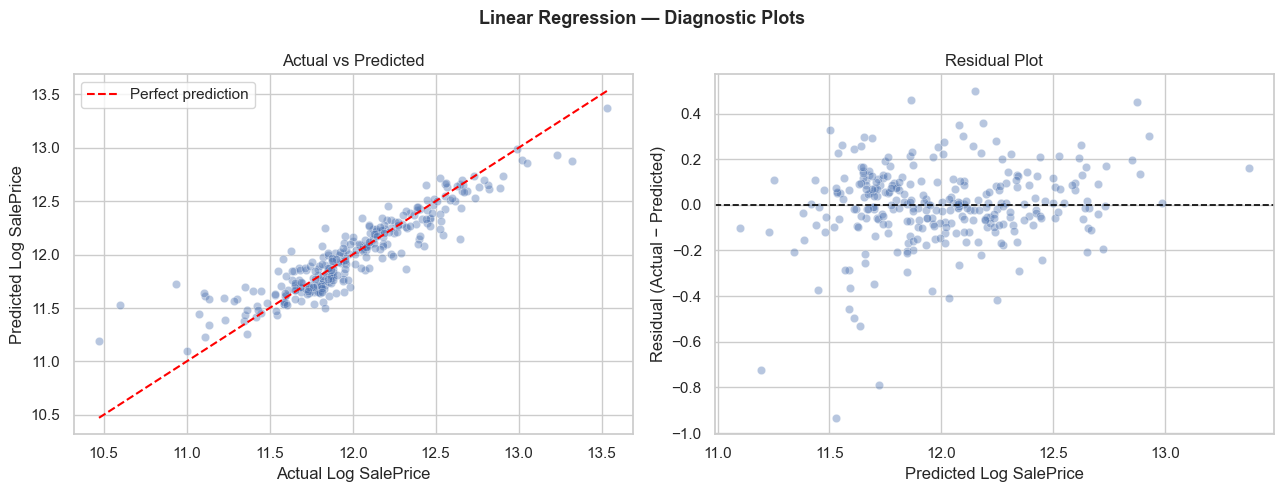

In [38]:
# Create an array defining Residuals (The physical numeric distance the model failed by per prediction)
residuals = y_h_test - y_h_pred

# Initializing Plot space.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Actual values vs Predicted values.
# If the model is perfect, all dots will lie exactly on a diagonal 45-degree angle.
sns.scatterplot(x=y_h_test, y=y_h_pred, alpha=0.4, ax=axes[0])
min_val, max_val = y_h_test.min(), y_h_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual Log SalePrice")
axes[0].set_ylabel("Predicted Log SalePrice")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# Plot 2: Residual Analysis Plot.
# Maps predictions against the error. We want to see total random scatter here centered strictly on 0.
# Any clear visible shape/cone/funnel implies the model is violating core mathematical properties of Linear Regression (homoscedasticity).
sns.scatterplot(x=y_h_pred, y=residuals, alpha=0.4, ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted Log SalePrice")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot")

plt.suptitle("Linear Regression — Diagnostic Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


C:\Users\siste\AppData\Local\Temp\ipykernel_7396\398963261.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_h_df, x="Coefficient", y="Feature", palette="coolwarm")


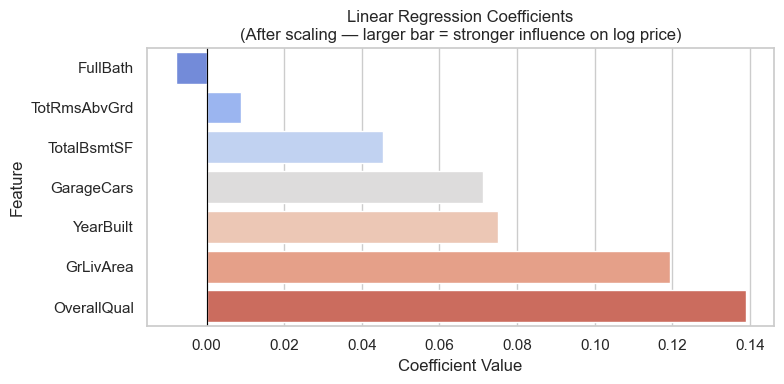

     Feature  Coefficient
    FullBath    -0.007960
TotRmsAbvGrd     0.008901
 TotalBsmtSF     0.045354
  GarageCars     0.071238
   YearBuilt     0.075124
   GrLivArea     0.119334
 OverallQual     0.138819

Intercept: 12.0307


In [39]:
# Output our finalized learned weights as a DataFrame.
# Because X is scaled (Z-scores), we can directly compare coefficient magnitudes against one another safely.
coef_h_df = pd.DataFrame({
    "Feature": HOUSE_FEATURES,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient")

# Plot the learned weights.
plt.figure(figsize=(8, 4))
sns.barplot(data=coef_h_df, x="Coefficient", y="Feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients\n(After scaling — larger bar = stronger influence on log price)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print(coef_h_df.to_string(index=False))

# The intercept is strictly what the model predicts the output is if ALL input Features were perfectly average (0-Z score).
print(f"\nIntercept: {lin_reg.intercept_:.4f}")


In [40]:
# Finally: Load the Kaggle unlabeled hold-out submission set!
test = pd.read_csv("test.csv")
print(f"Test set shape: {test.shape}")

HOUSE_FEATURES = [
    "GrLivArea",      
    "OverallQual",    
    "GarageCars",     
    "TotalBsmtSF",    
    "FullBath",       
    "YearBuilt",      
    "TotRmsAbvGrd",   
]
# Ensure we map only the exact same inputs our model specifically expects.
X_test_submission = test[HOUSE_FEATURES].copy()

# A brutal/simple imputation simply replacing missing Test data with the median to avoid un-scoreable NA outputs.
X_test_submission = X_test_submission.fillna(X_test_submission.median())

print(f"\nMissing values in test features:")
print(X_test_submission.isnull().sum())

# Execute the final transformations. *Do not re-fit the scaler here!*
X_test_submission_scaled = scaler_h.transform(X_test_submission)

# Fire predictions, returning them in a Logged state.
log_predictions = lin_reg.predict(X_test_submission_scaled)

# Apply exponential math minus 1 (expm1) to invert the log values back into normal currency values.
predicted_prices = np.expm1(log_predictions)

# Prepare Kaggle's specific requested submission format.
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predicted_prices
})

# Save to CSV for Kaggle submission
submission.to_csv('house_prices_submission.csv', index=False)

# Give yourselves a high five—we're done!
print(f"\n{'='*60}")
print(f"Predictions generated for {len(submission)} houses!")
print(f"{'='*60}")
print(f"\nPredicted Price Statistics:")
print(f"  Minimum:  ${predicted_prices.min():>12,.0f}")
print(f"  Median:   ${np.median(predicted_prices):>12,.0f}")
print(f"  Mean:     ${predicted_prices.mean():>12,.0f}")
print(f"  Maximum:  ${predicted_prices.max():>12,.0f}")
print(f"\nFirst 10 predictions:")
print(submission.head(10).to_string(index=False))
print(f"\n✓ Submission file saved as 'house_prices_submission.csv'")


Test set shape: (1459, 80)

Missing values in test features:
GrLivArea       0
OverallQual     0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
TotRmsAbvGrd    0
dtype: int64

Predictions generated for 1459 houses!

Predicted Price Statistics:
  Minimum:  $      64,529
  Median:   $     159,998
  Mean:     $     176,516
  Maximum:  $   1,088,393

First 10 predictions:
  Id     SalePrice
1461 115225.223783
1462 147110.180538
1463 163027.557927
1464 180822.897650
1465 208014.809805
1466 177699.619980
1467 165224.947647
1468 172736.757234
1469 192802.923176
1470 116163.067293

✓ Submission file saved as 'house_prices_submission.csv'


Submit to kaggle
kaggle competitions submit -c house-prices-advanced-regression-techniques -f house_prices_submission.csv -m "My submission"